<a href="https://colab.research.google.com/github/sibandze/ml-practice/blob/titanic_survivor_project/projects/titanic_survivor_project/notebooks/titanic_survivor_eda_and_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Titanic Sirvivor Prediction**

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
titanicsurvivorpath = '/content/drive/MyDrive/ML/projects/titanic_survival_project/raw/titanic.csv'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

titanic_survivor_raw_dataframe = pd.read_csv(titanicsurvivorpath)
titanic_survivor_raw_dataframe.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
titanic_survivor_raw_dataframe.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

<Axes: >

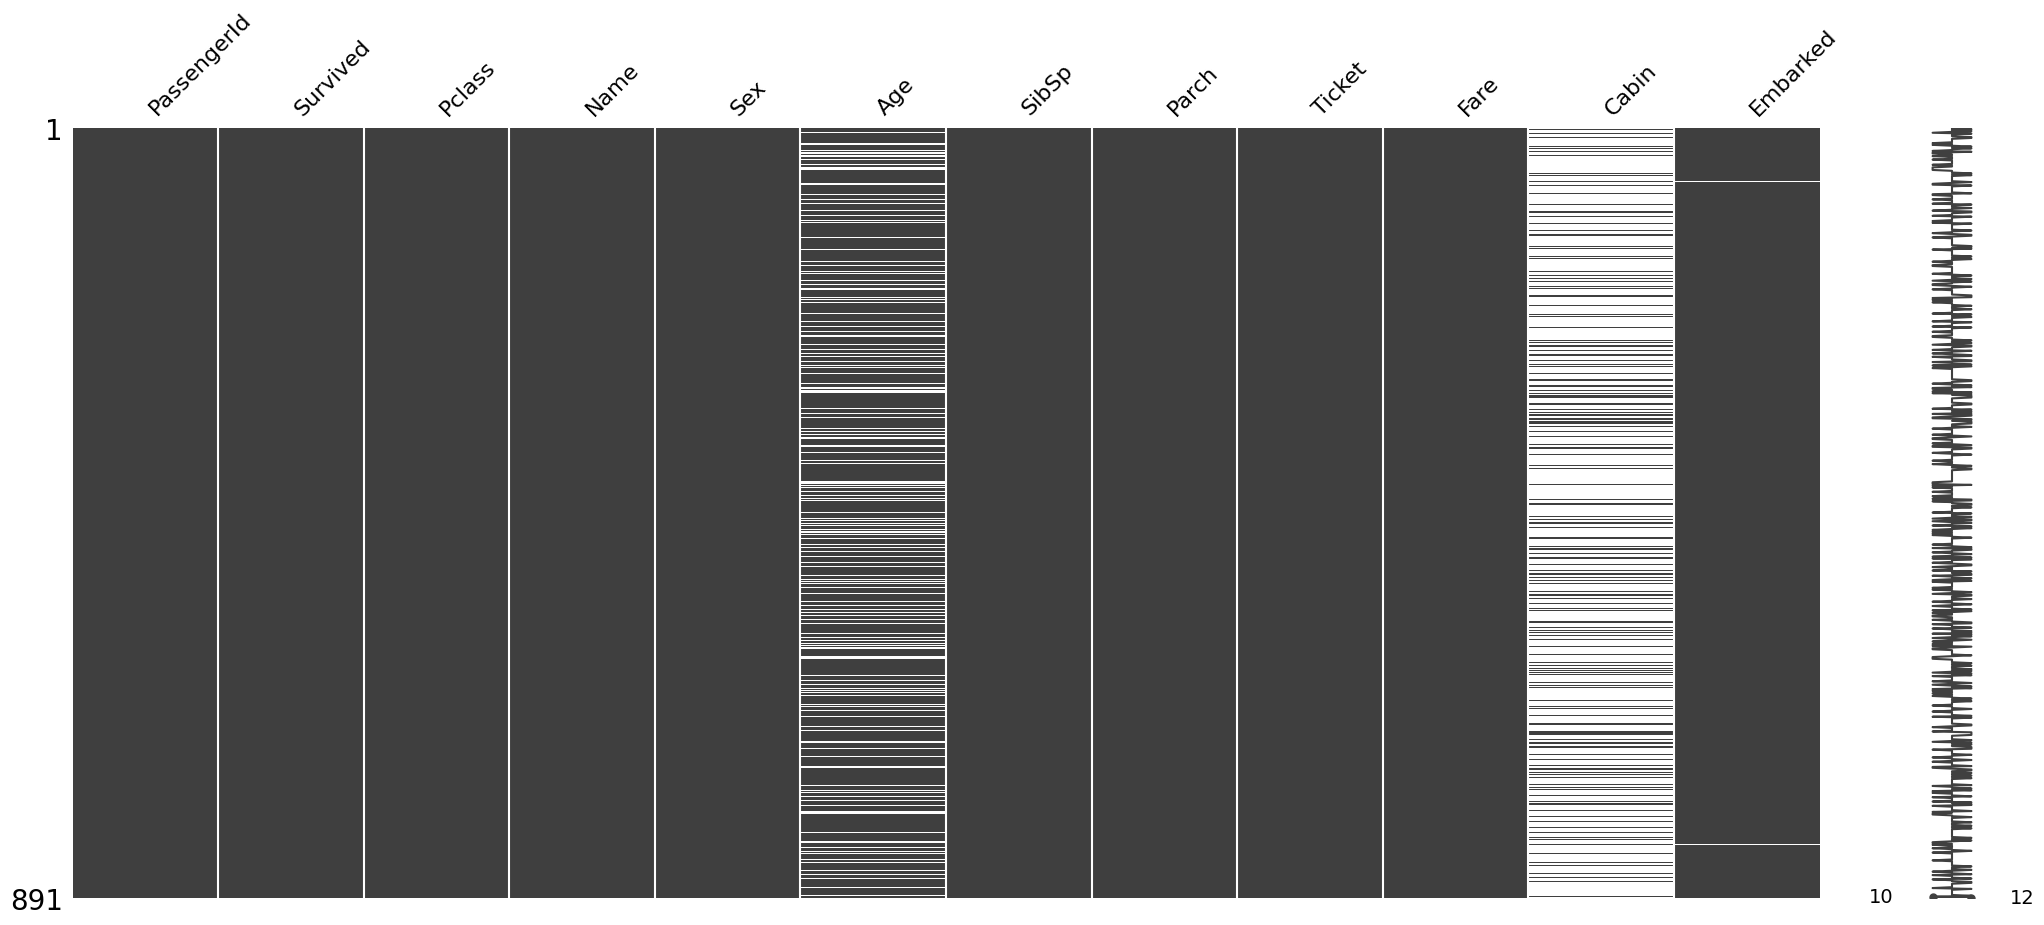

In [ ]:
import missingno as msno
msno.matrix(titanic_survivor_raw_dataframe)

In [ ]:
null_values = titanic_survivor_raw_dataframe.isnull()
null_count = null_values.sum()
null_count
#null_values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
titanic_survivor_raw_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic_survivor_raw_dataframe.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Handle missing values
First we will keep a copy of the dataframe to be able to compare the data later and see if the transformation did not change the discribution of change columns.

In [ ]:
titanic_df_before_imputation = titanic_survivor_raw_dataframe.copy()

# Task 1
## Handle missing 'Age' values

Calculate the median age for each combination of 'Pclass' and 'Sex' from the `titanic_survivor_raw_dataframe`, then use these medians to impute the missing 'Age' values in the same DataFrame, and finally verify that all 'Age' null values have been filled.

### Calculate median ages
Calculate the median age for each combination of 'Pclass' and 'Sex' from the `titanic_survivor_raw_dataframe`.


**Reasoning**:
To calculate the median age for each combination of 'Pclass' and 'Sex', I will group the 'titanic_survivor_raw_dataframe' by these two columns, select the 'Age' column, and then apply the median aggregation.



In [ ]:
median_ages_by_pclass_sex = titanic_survivor_raw_dataframe.groupby(['Pclass', 'Sex'])['Age'].median()
print(median_ages_by_pclass_sex)

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


## Impute missing 'Age' values

Fill the missing 'Age' values in the `titanic_survivor_raw_dataframe` with the calculated median ages, grouping by 'Pclass' and 'Sex'.


**Reasoning**:
To impute the missing 'Age' values, I will group the DataFrame by 'Pclass' and 'Sex', and then use the `transform` method with `fillna` and `median` to replace NaN values in 'Age' with the median age of their respective groups.



In [ ]:
titanic_survivor_raw_dataframe['Age'] = titanic_survivor_raw_dataframe.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
print("Missing 'Age' values after imputation:")
print(titanic_survivor_raw_dataframe['Age'].isnull().sum())

Missing 'Age' values after imputation:
0


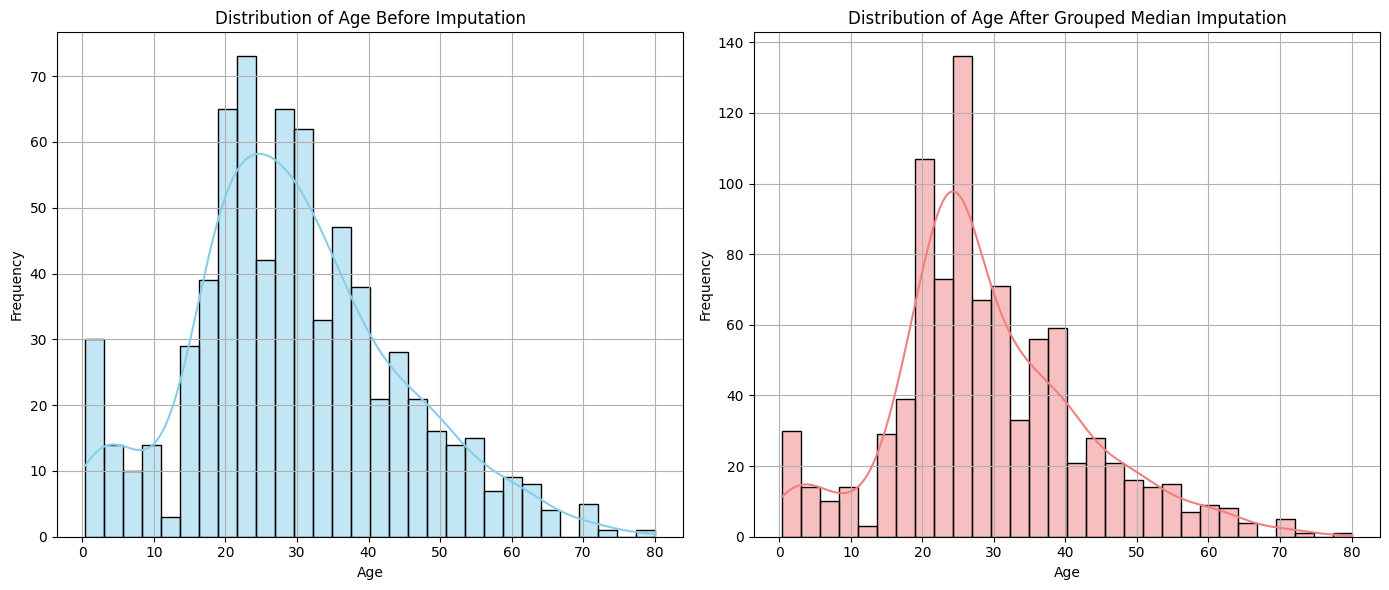

In [ ]:
plt.figure(figsize=(14, 6)) # Adjust figure size for two plots

# Plot 1: Age distribution BEFORE imputation (from the copied DataFrame)
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(titanic_df_before_imputation['Age'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Age Before Imputation')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)

# Plot 2: Age distribution AFTER imputation (from the original, modified DataFrame)
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(titanic_survivor_raw_dataframe['Age'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of Age After Grouped Median Imputation')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()

# Task 2
## Handle missing 'Embarked' value
Find the mode 'Embarked' `titanic_survivor_raw_dataframe`, then use this value to impute the missing 'Embarked' values in the same DataFrame, and finally verify that all 'Embarked' null values have been filled.



In [ ]:
# Find the mode (most frequent value) of the 'Embarked' column
mode_embarked = titanic_survivor_raw_dataframe['Embarked'].mode()[0]
print(f"\nMode of 'Embarked': {mode_embarked}")

# Fill the null (NaN) values in the 'Embarked' column with the mode
titanic_survivor_raw_dataframe['Embarked'].fillna(mode_embarked, inplace=True)

# Verify that the null values have been filled
print(f"Number of missing 'Embarked' values after imputation: {titanic_survivor_raw_dataframe['Embarked'].isnull().sum()}")


Mode of 'Embarked': S
Number of missing 'Embarked' values after imputation: 0


/tmp/ipython-input-3352321275.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_survivor_raw_dataframe['Embarked'].fillna(mode_embarked, inplace=True)


In [ ]:
# Task 3
## Create a new column 'HasCabin'


In [ ]:
titanic_survivor_raw_dataframe['HasCabin'] = titanic_survivor_raw_dataframe['Cabin'].notna().astype(int)
print(titanic_survivor_raw_dataframe[['Cabin', 'HasCabin']].head())

  Cabin  HasCabin
0   NaN         0
1   C85         1
2   NaN         0
3  C123         1
4   NaN         0


In [ ]:
print("Missing values in each column after previous steps:")
print(titanic_survivor_raw_dataframe.isnull().sum())

Missing values in each column after previous steps:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
HasCabin         0
dtype: int64


## Columns for the final transformed DataFrame

*   `Survived`: The target variable.
*   `Pclass`: Passenger class.
*   `Sex`: Gender of the passenger.
*   `Age`: Age of the passenger (imputed).
*   `SibSp`: Number of siblings/spouses aboard.
*   `Parch`: Number of parents/children aboard.
*   `Fare`: Passenger fare.
*   `Embarked`: Port of embarkation (imputed).
*   `HasCabin`: A new binary feature indicating if a passenger had a cabin.


In [ ]:
columns_to_keep = [
    'Survived',
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'HasCabin'
]

print("Columns selected for the final transformed DataFrame:")
print(columns_to_keep)

Columns selected for the final transformed DataFrame:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin']


## Create the final training DataFrame and extract the target variable

First, we'll create the `titanic_transformed_df` by selecting only the `columns_to_keep`. Then, we'll convert the categorical features ('Sex', 'Embarked', 'Pclass') into numerical representations using one-hot encoding. Finally, we'll separate the `Survived` column into our target variable `y` and the remaining features into our training data `X`.

In [ ]:
titanic_transformed_df = titanic_survivor_raw_dataframe[columns_to_keep].copy()

In [ ]:
# One-hot encode categorical features
titanic_transformed_df = pd.get_dummies(titanic_transformed_df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)


In [ ]:
# Separate target variable (y) and features (X)
X = titanic_transformed_df.drop('Survived', axis=1)
y = titanic_transformed_df['Survived']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Shape of X: (891, 10)
Shape of y: (891,)

First 5 rows of X:


,Age,SibSp,Parch,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,22.0,1,0,7.2500,0,True,False,True,False,True
1,38.0,1,0,71.2833,1,False,False,False,False,False
2,26.0,0,0,7.9250,0,False,False,True,False,True
3,35.0,1,0,53.1000,1,False,False,True,False,False
4,35.0,0,0,8.0500,0,True,False,True,False,True



First 5 rows of y:


,Survived
0,0
1,1
2,1
3,1
4,0


# Split training testing sets

In [ ]:
from sklearn.model_selection import train_test_split

train_size = 0.8
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=268)

## Evaluate Models with Classification Metrics

Now, let's calculate and display more suitable classification metrics like Accuracy, Precision, Recall, and F1-score for each model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [
    LogisticRegression(solver='liblinear', random_state=268, max_iter = 1000),
    DecisionTreeClassifier(random_state = 268),
    RandomForestClassifier(random_state = 268),
    SVC(random_state = 268, probability=True),
    KNeighborsClassifier(),
]

classification_metrics = {}

for model in models:
    print(f"\nEvaluating {type(model).__name__}...")
    # Ensure the model is trained (it should be from previous steps, but good practice)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    classification_metrics[type(model).__name__] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

print("\n--- Summary of Classification Metrics ---")
for name, metrics in classification_metrics.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


Evaluating LogisticRegression...
  Accuracy: 0.7821
  Precision: 0.7778
  Recall: 0.6087
  F1-Score: 0.6829

Evaluating DecisionTreeClassifier...
  Accuracy: 0.7430
  Precision: 0.6716
  Recall: 0.6522
  F1-Score: 0.6618

Evaluating RandomForestClassifier...
  Accuracy: 0.7765
  Precision: 0.7302
  Recall: 0.6667
  F1-Score: 0.6970

Evaluating SVC...
  Accuracy: 0.6872
  Precision: 0.7407
  Recall: 0.2899
  F1-Score: 0.4167

Evaluating KNeighborsClassifier...
  Accuracy: 0.6872
  Precision: 0.6032
  Recall: 0.5507
  F1-Score: 0.5758

--- Summary of Classification Metrics ---

LogisticRegression:
  Accuracy: 0.7821
  Precision: 0.7778
  Recall: 0.6087
  F1-Score: 0.6829

DecisionTreeClassifier:
  Accuracy: 0.7430
  Precision: 0.6716
  Recall: 0.6522
  F1-Score: 0.6618

RandomForestClassifier:
  Accuracy: 0.7765
  Precision: 0.7302
  Recall: 0.6667
  F1-Score: 0.6970

SVC:
  Accuracy: 0.6872
  Precision: 0.7407
  Recall: 0.2899
  F1-Score: 0.4167

KNeighborsClassifier:
  Accuracy: 0.687